In [10]:
#Cell 1, Load raw NBA data


import pandas as pd

# List of seasons you want to load (2015 to 2025)
years = list(range(2015, 2026))
all_seasons = []

for year in years:
    print(f"Loading season {year}...")

    # Construct the URL for that year's per-game stats
    url = f"https://www.basketball-reference.com/leagues/NBA_{year}_per_game.html"

    try:
        # Read the first table from the page
        df = pd.read_html(url)[0]

        # Remove extra header rows that get repeated in the HTML
        df = df[df['Player'] != 'Player']

        # Convert all stat columns to numeric (skip first 5 non-stat columns)
        for col in df.columns[5:]:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        # Add a column for the season
        df['Year'] = year

        # Store this year's cleaned DataFrame
        all_seasons.append(df)

    except Exception as e:
        print(f"Could not load {year}: {e}")

# Combine all years into one big DataFrame
nba_df = pd.concat(all_seasons, ignore_index=True)

# Preview the result
print("All years loaded. Combined shape:", nba_df.shape)
nba_df.head()


Loading season 2015...
Loading season 2016...
Loading season 2017...
Loading season 2018...
Loading season 2019...
Loading season 2020...
Loading season 2021...
Loading season 2022...
Loading season 2023...
Loading season 2024...
Loading season 2025...
All years loaded. Combined shape: (7524, 32)


,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Year
0,1.0,Russell Westbrook,26.0,OKC,PG,67.0,67.0,34.4,9.4,22.0,...,5.4,7.3,8.6,2.1,0.2,4.4,2.7,28.1,NaN,2015
1,2.0,James Harden,25.0,HOU,SG,81.0,81.0,36.8,8.0,18.1,...,4.7,5.7,7.0,1.9,0.7,4.0,2.6,27.4,NaN,2015
2,3.0,Kevin Durant,26.0,OKC,SF,27.0,27.0,33.8,8.8,17.3,...,6.0,6.6,4.1,0.9,0.9,2.7,1.5,25.4,NaN,2015
3,4.0,LeBron James,30.0,CLE,SF,69.0,69.0,36.1,9.0,18.5,...,5.3,6.0,7.4,1.6,0.7,3.9,2.0,25.3,NaN,2015
4,5.0,Anthony Davis,21.0,NOP,PF,68.0,68.0,36.1,9.4,17.6,...,7.7,10.2,2.2,1.5,2.9,1.4,2.1,24.4,NaN,2015


In [11]:
#Cell 2, Clean data


# Keep only the last row per player per season — usually the 'TOT' (total stats)
nba_df = nba_df.sort_values(['Player', 'Year', 'Team'])  # Sort so 'TOT' comes last
nba_df = nba_df.drop_duplicates(subset=['Player', 'Year'], keep='last')  # Keep last = 'TOT'

# Filter out players who averaged less than 15 minutes per game
nba_df = nba_df[nba_df['MP'] >= 15]

# Reset index
nba_df = nba_df.reset_index(drop=True)

# Check the shape and preview
print("Cleaned shape:", nba_df.shape)
nba_df[['Player', 'Year', 'Team', 'MP', 'PTS', 'AST', 'TRB']].head()



Cleaned shape: (3807, 32)


,Player,Year,Team,MP,PTS,AST,TRB
0,A.J. Green,2025,MIL,22.7,7.4,1.5,2.4
1,A.J. Lawson,2025,TOR,18.7,9.1,1.2,3.3
2,AJ Griffin,2023,ATL,19.5,8.9,1.0,2.1
3,AJ Johnson,2025,WAS,27.0,9.1,3.1,2.4
4,Aaron Brooks,2015,CHI,23.0,11.6,3.2,2.0


In [12]:
#Cell 3, Add AllStar column


#Save the multi-year cleaned dataset (optional)
nba_df.to_csv("nba_2015_2025_cleaned.csv", index=False)
print("Saved cleaned dataset as 'nba_2015_2025_cleaned.csv'")



Saved cleaned dataset as 'nba_2015_2025_cleaned.csv'


In [13]:
# Cell 4, Label AllStars from 2015 to 2025


# Dictionary of All-Star players by year (sample shown for 2023; you will need to continue filling this)
all_star_dict = {
    2015: ["Stephen Curry", "Kobe Bryant", "Anthony Davis", "Marc Gasol", "Blake Griffin", "James Harden", "Klay Thompson", "Chris Paul", "Russell Westbrook", "LaMarcus Aldridge", "Tim Duncan", "Kevin Durant", "Damian Lillard", "Dirk Nowitzki",
           "John Wall", "Kyle Lowry", "LeBron James", "Pau Gasol", "Carmelo Anthony", "Jimmy Butler", "Chris Bosh", "Paul Millsap", "Kyrie Irving", "Jeff Teague", "Al Horford", "DeMar DeRozan"],
    2016: ["Stephen Curry", "Russell Westbrook", "Kobe Bryant", "Kevin Durant", "Kawhi Leonard", "Chris Paul", "James Harden", "Klay Thompson", "Draymond Green", "Anthony Davis", "DeMarcus Cousins", "LaMarcus Aldridge",
           "LeBron James", "Paul George", "Carmelo Anthony", "Kyle Lowry", "Dwyane Wade", "DeMar DeRozan", "Jimmy Butler", "Isaiah Thomas", "Paul Millsap", "Andre Drummond", "John Wall", "Chris Bosh"],
    2017: ["Kyrie Irving", "DeMar DeRozan", "LeBron James", "Jimmy Butler", "Giannis Antetokounmpo", "Isaiah Thomas", "John Wall", "Kevin Love", "Kyle Lowry", "Paul George", "Kemba Walker", "Paul Millsap",
           "Stephen Curry", "James Harden", "Kevin Durant", "Kawhi Leonard", "Anthony Davis", "Russell Westbrook", "Klay Thompson", "Draymond Green", "DeMarcus Cousins", "Marc Gasol", "DeAndre Jordan", "Gordon Hayward"],
    2018: ["Kyrie Irving", "LeBron James", "Anthony Davis", "DeMarcus Cousins", "Kevin Durant", "LaMarcus Aldridge", "Bradley Beal", "Kevin Love", "Russell Westbrook", "Victor Oladipo", "Kristaps Porziņģis", "John Wall", "Paul George", "Andre Drummond", "Goran Dragić", "Kemba Walker",
           "James Harden", "DeMar DeRozan", "Stephen Curry", "Giannis Antetokounmpo", "Joel Embiid", "Damian Lillard", "Jimmy Butler", "Draymond Green", "Kyle Lowry", "Klay Thompson", "Karl-Anthony Towns", "Al Horford"],
    2019: ["Kemba Walker", "Kyrie Irving", "Kawhi Leonard", "Giannis Antetokounmpo", "Joel Embiid", "Kyle Lowry", "Victor Oladipo", "Khris Middleton", "Bradley Beal", "Ben Simmons", "Blake Griffin", "Nikola Vučević", "Dwyane Wade", "D'Angelo Russell",
       "Stephen Curry", "James Harden", "Kevin Durant", "Paul George", "LeBron James", "Russell Westbrook", "Damian Lillard", "Klay Thompson", "Anthony Davis", "LaMarcus Aldridge", "Nikola Jokić", "Karl-Anthony Towns", "Dirk Nowitzki"],
    2020: ["Kemba Walker", "Trae Young", "Giannis Antetokounmpo", "Pascal Siakam", "Joel Embiid", "Kyle Lowry", "Ben Simmons", "Jimmy Butler", "Khris Middleton", "Bam Adebayo", "Jayson Tatum", "Domantas Sabonis",
       "James Harden", "Luka Dončić", "LeBron James", "Kawhi Leonard", "Anthony Davis", "Chris Paul", "Russell Westbrook", "Damian Lillard", "Donovan Mitchell", "Brandon Ingram", "Nikola Jokić", "Rudy Gobert", "Devin Booker"],
    2021: ["Bradley Beal", "Kyrie Irving", "Giannis Antetokounmpo", "Kevin Durant", "Joel Embiid", "Jaylen Brown", "James Harden", "Zach LaVine", "Ben Simmons", "Julius Randle", "Domantas Sabonis", "Jayson Tatum", "Nikola Vučević",
       "Stephen Curry", "Luka Dončić", "LeBron James", "Kawhi Leonard", "Nikola Jokić", "Devin Booker", "Mike Conley", "Damian Lillard", "Donovan Mitchell", "Chris Paul", "Anthony Davis", "Paul George", "Zion Williamson", "Rudy Gobert"],
    2022: ["Trae Young", "DeMar DeRozan", "Joel Embiid", "Kevin Durant", "Giannis Antetokounmpo", "LaMelo Ball", "Darius Garland", "James Harden", "Zach LaVine", "Fred VanVleet", "Jimmy Butler", "Khris Middleton", "Jayson Tatum", "Jarrett Allen",
       "Stephen Curry", "Ja Morant", "Nikola Jokić", "LeBron James", "Andrew Wiggins", "Devin Booker", "Luka Dončić", "Donovan Mitchell", "Dejounte Murray", "Chris Paul", "Draymond Green", "Rudy Gobert", "Karl-Anthony Towns"],
    2023: ["Kyrie Irving", "Donovan Mitchell", "Giannis Antetokounmpo", "Kevin Durant", "Jayson Tatum", "Jaylen Brown", "DeMar DeRozan", "Tyrese Haliburton", "Jrue Holiday", "Julius Randle", "Bam Adebayo", "Joel Embiid", "Pascal Siakam",
       "Stephen Curry", "Luka Dončić", "Nikola Jokić", "LeBron James", "Zion Williamson", "Shai Gilgeous-Alexander", "Damian Lillard", "Ja Morant", "Paul George", "Jaren Jackson Jr.", "Lauri Markkanen", "Domantas Sabonis", "Anthony Edwards", "De'Aaron Fox"],
    2024: ["Tyrese Haliburton", "Damian Lillard", "Giannis Antetokounmpo", "Jayson Tatum", "Joel Embiid", "Jalen Brunson", "Tyrese Maxey", "Donovan Mitchell", "Trae Young", "Paolo Banchero", "Scottie Barnes", "Jaylen Brown", "Julius Randle", "Bam Adebayo",
       "Luka Dončić", "Shai Gilgeous-Alexander", "Kevin Durant", "LeBron James", "Nikola Jokić", "Devin Booker", "Stephen Curry", "Anthony Edwards", "Paul George", "Kawhi Leonard", "Karl-Anthony Towns", "Anthony Davis"],
    2025: ["Jalen Brunson", "Donovan Mitchell", "Jayson Tatum", "Giannis Antetokounmpo", "Karl-Anthony Towns", "Jaylen Brown", "Cade Cunningham", "Darius Garland", "Tyler Herro", "Damian Lillard", "Evan Mobley", "Pascal Siakam", "Trae Young",
       "Shai Gilgeous-Alexander", "Stephen Curry", "LeBron James", "Kevin Durant", "Nikola Jokić", "Anthony Edwards", "James Harden", "Jaren Jackson Jr.", "Jalen Williams", "Anthony Davis", "Alperen Şengün", "Victor Wembanyama", "Kyrie Irving"]

}

# Add a new column 'AllStar' to label if player was an All-Star that season
def label_all_stars(df, all_star_dict):
    df['AllStar'] = df.apply(
        lambda row: 1 if row['Player'] in all_star_dict.get(row['Year'], []) else 0, axis=1
    )
    return df

# Apply the labeling function
df_labeled = label_all_stars(df.copy(), all_star_dict)

# Preview results
df_labeled[["Player", "Year", "AllStar"]].head(10)


,Player,Year,AllStar
0,Shai Gilgeous-Alexander,2025,1
1,Giannis Antetokounmpo,2025,1
2,Nikola Jokić,2025,1
3,Luka Dončić,2025,0
4,Luka Dončić,2025,0
5,Luka Dončić,2025,0
6,Anthony Edwards,2025,1
7,Jayson Tatum,2025,1
8,Kevin Durant,2025,1
9,Tyrese Maxey,2025,0


In [14]:
# Cell 5, Feature Selection & Train-Test Split


# Check available columns
print(df_labeled.columns)

# Drop only if the column exists
df_model = df_labeled.drop(columns=[col for col in ["Player", "Pos"] if col in df_labeled.columns])

# OPTIONAL: Instead of dropna (which might remove everything), fill missing with zeros
df_model = df_model.fillna(0)

# Separate features and target
X = df_model.drop(columns=["AllStar"])
y = df_model["AllStar"]

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Quick check of the shapes
print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])



Index(['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP', 'FG', 'FGA',
       'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA',
       'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
       'Awards', 'Year', 'AllStar'],
      dtype='object')
Training samples: 588
Test samples: 148


In [15]:
#Cell 6, Training cell


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Define features and target
X = df_labeled[['PTS', 'AST', 'TRB', 'STL', 'BLK', 'MP']]
y = df_labeled['AllStar']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

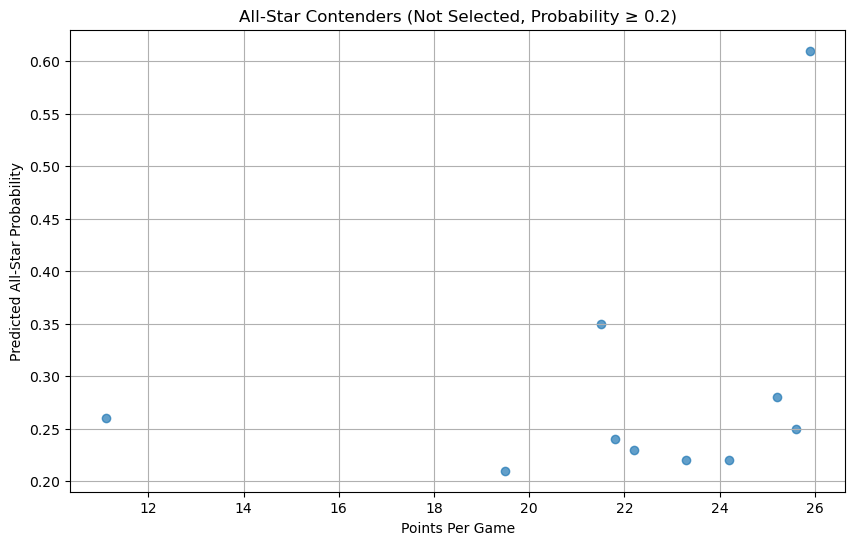

,Player,Year,PTS,AST,TRB,MP,AllStar_Prob
12,Paolo Banchero,2025,25.9,4.8,7.5,34.4,0.61
45,Kawhi Leonard,2025,21.5,3.1,5.9,31.9,0.35
14,LaMelo Ball,2025,25.2,7.4,4.9,32.0,0.28
184,Walker Kessler,2025,11.1,1.7,12.2,30.0,0.26
13,Devin Booker,2025,25.6,7.1,4.1,37.3,0.25
43,Norman Powell,2025,21.8,2.1,3.2,32.6,0.24
41,Brandon Ingram,2025,22.2,5.2,5.6,33.1,0.23
25,Franz Wagner,2025,24.2,4.7,5.7,33.7,0.22
34,Zach LaVine,2025,23.3,4.2,4.3,35.2,0.22
58,Kristaps Porziņģis,2025,19.5,2.1,6.8,28.8,0.21


In [25]:
# Contend


import matplotlib.pyplot as plt

# Predict All-Star probabilities for all players
X_all = df_labeled[['PTS', 'AST', 'TRB', 'STL', 'BLK', 'MP']]
df_labeled['AllStar_Prob'] = model.predict_proba(X_all)[:, 1]

# Filter: players who were NOT All-Stars, but had probability ≥ 0.2
contenders = df_labeled[(df_labeled['AllStar'] == 0) & (df_labeled['AllStar_Prob'] >= 0.2)]

# Scatter plot: visualize the contenders
plt.figure(figsize=(10, 6))
plt.scatter(contenders['PTS'], contenders['AllStar_Prob'], alpha=0.7)
plt.xlabel('Points Per Game')
plt.ylabel('Predicted All-Star Probability')
plt.title('All-Star Contenders (Not Selected, Probability ≥ 0.2)')
plt.grid(True)
plt.show()

# Show top 15 contenders with high probability
contenders[['Player', 'Year', 'PTS', 'AST', 'TRB', 'MP', 'AllStar_Prob']].sort_values(by='AllStar_Prob', ascending=False).head(15)




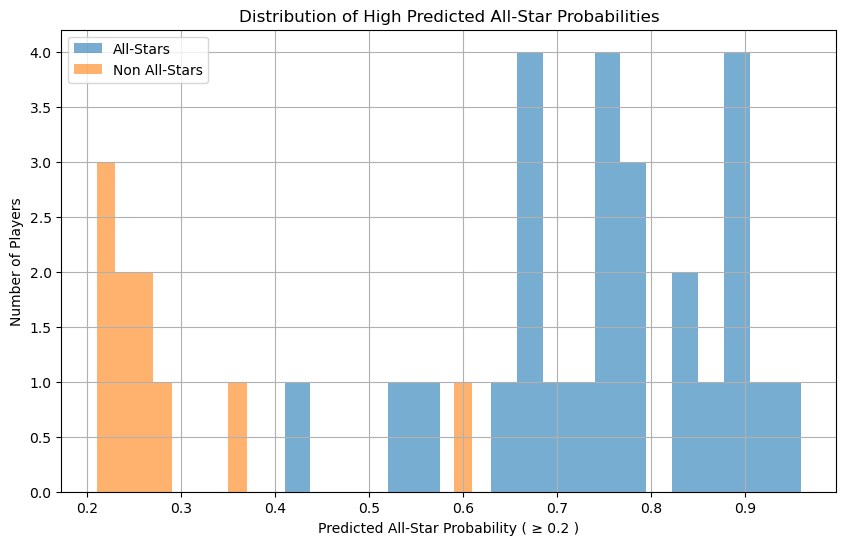

In [27]:
# All-Star Probability Distribution (Only players with probability > 0.2)

import matplotlib.pyplot as plt

# Filter players with predicted All-Star probability ≥ 0.2
high_prob = df_labeled[df_labeled['AllStar_Prob'] >= 0.2]

# Separate into actual All-Stars and Non-All-Stars
allstars = high_prob[high_prob['AllStar'] == 1]
non_allstars = high_prob[high_prob['AllStar'] == 0]

# Plot the histograms
plt.figure(figsize=(10, 6))
plt.hist(allstars['AllStar_Prob'], bins=20, alpha=0.6, label='All-Stars')
plt.hist(non_allstars['AllStar_Prob'], bins=20, alpha=0.6, label='Non All-Stars')
plt.xlabel('Predicted All-Star Probability ( ≥ 0.2 )')
plt.ylabel('Number of Players')
plt.title('Distribution of High Predicted All-Star Probabilities')
plt.legend()
plt.grid(True)
plt.show()


In [32]:
# Show snubbed players 


# Predict All-Star probability for all players
X_all = df_labeled[['PTS', 'AST', 'TRB', 'STL', 'BLK', 'MP']]
df_labeled['AllStar_Prob'] = model.predict_proba(X_all)[:, 1]

# Keep only players who were NOT All-Stars
potential_snubs = df_labeled[df_labeled['AllStar'] == 0]

# Filter: only players with predicted All-Star probability ≥ 0.2
snubs = potential_snubs[potential_snubs['AllStar_Prob'] >= 0.2]

# Show top 15 snubbed players by probability
snubs[['Player', 'Year', 'PTS', 'AST', 'TRB', 'MP', 'AllStar_Prob']].sort_values(by='AllStar_Prob', ascending=False).head(15)



,Player,Year,PTS,AST,TRB,MP,AllStar_Prob
12,Paolo Banchero,2025,25.9,4.8,7.5,34.4,0.61
45,Kawhi Leonard,2025,21.5,3.1,5.9,31.9,0.35
14,LaMelo Ball,2025,25.2,7.4,4.9,32.0,0.28
184,Walker Kessler,2025,11.1,1.7,12.2,30.0,0.26
13,Devin Booker,2025,25.6,7.1,4.1,37.3,0.25
43,Norman Powell,2025,21.8,2.1,3.2,32.6,0.24
41,Brandon Ingram,2025,22.2,5.2,5.6,33.1,0.23
25,Franz Wagner,2025,24.2,4.7,5.7,33.7,0.22
34,Zach LaVine,2025,23.3,4.2,4.3,35.2,0.22
58,Kristaps Porziņģis,2025,19.5,2.1,6.8,28.8,0.21


In [49]:
#Test player


# Custom player stats (you can change these numbers)
custom_player = pd.DataFrame([{
    'PTS': 0,  # Points per game
    'AST': 30,   # Assists per game
    'TRB': 30,   # Total rebounds
    'STL': 30,   # Steals per game
    'BLK': 30,   # Blocks per game
    'MP': 35    # Minutes per game
}])

# Predict with the trained model
prediction = model.predict(custom_player)

# Show result
print("All-Star Prediction:", "⭐ YES!" if prediction[0] == 1 else "❌ Nope.")


All-Star Prediction: ❌ Nope.
